# 📊 Naive Bayes Comparison Notebook
So sánh Custom vs Sklearn Naive Bayes trên tập digits.

## 1. Import thư viện

In [1]:
import numpy as np
import time

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import classification_report, confusion_matrix

## 2. Load và chia dữ liệu

In [2]:
data = load_digits()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data ready!")

Data ready!


## 3. Custom Multinomial Naive Bayes

In [3]:
class CustomMultinomialNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.class_log_prior = []
        self.feature_log_prob = []

        for c in self.classes:
            X_c = X[y == c]
            prior = X_c.shape[0] / X.shape[0]
            self.class_log_prior.append(np.log(prior))

            feature_count = X_c.sum(axis=0) + self.alpha
            total_count = feature_count.sum()
            prob = feature_count / total_count

            self.feature_log_prob.append(np.log(prob))

        self.class_log_prior = np.array(self.class_log_prior)
        self.feature_log_prob = np.array(self.feature_log_prob)

    def predict(self, X):
        log_probs = X @ self.feature_log_prob.T + self.class_log_prior
        return self.classes[np.argmax(log_probs, axis=1)]

## 4. Custom Bernoulli Naive Bayes

In [4]:
class CustomBernoulliNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        X = (X > 0).astype(int)
        self.classes = np.unique(y)

        self.class_log_prior = []
        self.feature_log_prob = []

        for c in self.classes:
            X_c = X[y == c]
            prior = X_c.shape[0] / X.shape[0]
            self.class_log_prior.append(np.log(prior))

            prob = (X_c.sum(axis=0) + self.alpha) / (X_c.shape[0] + 2*self.alpha)
            self.feature_log_prob.append(np.log(prob))

        self.class_log_prior = np.array(self.class_log_prior)
        self.feature_log_prob = np.array(self.feature_log_prob)

    def predict(self, X):
        X = (X > 0).astype(int)
        log_probs = X @ self.feature_log_prob.T + self.class_log_prior
        return self.classes[np.argmax(log_probs, axis=1)]

## 5. Khởi tạo model

In [5]:
models = {
    "Custom Multinomial NB": CustomMultinomialNB(),
    "Custom Bernoulli NB": CustomBernoulliNB(),
    "Sklearn Multinomial NB": MultinomialNB(),
    "Sklearn Bernoulli NB": BernoulliNB()
}

train_time = {}
results = {}

## 6. Train model

In [6]:
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time[name] = time.time() - start

## 7. Đánh giá

In [7]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = np.mean(y_pred == y_test)
    results[name] = acc

    print("\n", name)
    print("Accuracy:", round(acc, 4))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))


 Custom Multinomial NB
Accuracy: 0.9111
Confusion Matrix:
 [[32  0  0  0  1  0  0  0  0  0]
 [ 0 20  4  0  0  0  0  0  2  2]
 [ 0  1 31  0  0  0  0  0  1  0]
 [ 0  0  1 30  0  0  0  0  2  1]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 39  1  0  0  7]
 [ 0  0  0  0  1  0 34  0  0  0]
 [ 0  0  0  0  0  0  0 34  0  0]
 [ 0  2  0  0  0  0  0  0 28  0]
 [ 0  0  0  0  1  1  0  3  1 34]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       0.87      0.71      0.78        28
           2       0.86      0.94      0.90        33
           3       1.00      0.88      0.94        34
           4       0.94      1.00      0.97        46
           5       0.97      0.83      0.90        47
           6       0.97      0.97      0.97        35
           7       0.92      1.00      0.96        34
           8       0.82      0.93      0.88        30
           9       0.77      0.85      0.81 

## 8. So sánh kết quả

In [8]:
print("\n===== COMPARISON =====")
for name in models:
    print(f"{name:30} | Acc: {results[name]:.4f} | Time: {train_time[name]:.4f}s")


===== COMPARISON =====
Custom Multinomial NB          | Acc: 0.9111 | Time: 0.0072s
Custom Bernoulli NB            | Acc: 0.7667 | Time: 0.0040s
Sklearn Multinomial NB         | Acc: 0.9111 | Time: 0.0000s
Sklearn Bernoulli NB           | Acc: 0.8639 | Time: 0.0080s


## 9. Model tốt nhất

In [9]:
best_model = max(results, key=results.get)
print("Best model:", best_model)

Best model: Custom Multinomial NB


## 10. Bảng kết quả

In [10]:
import pandas as pd

df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": list(results.values()),
    "Training Time (s)": list(train_time.values())
})

display(df)

,Model,Accuracy,Training Time (s)
0,Custom Multinomial NB,0.911111,0.007226
1,Custom Bernoulli NB,0.766667,0.003967
2,Sklearn Multinomial NB,0.911111,0.000000
3,Sklearn Bernoulli NB,0.863889,0.007965


## 11. Visualization

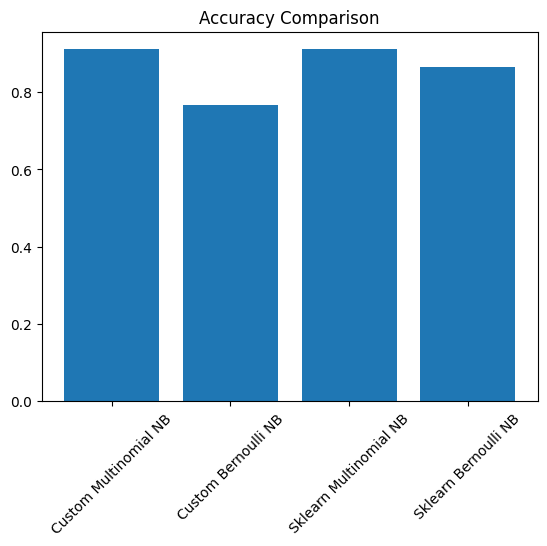

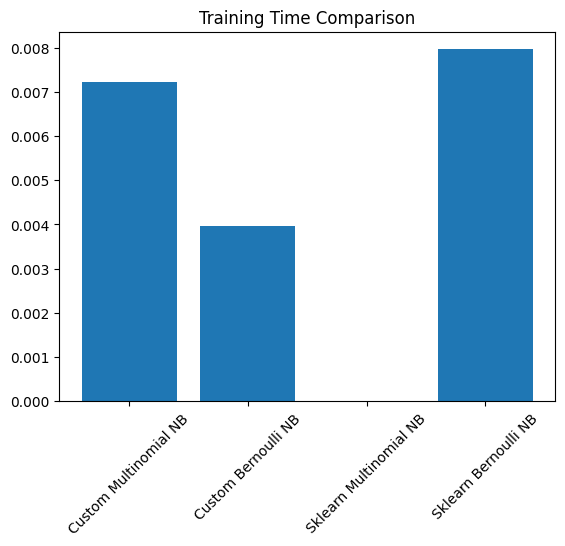

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df["Model"], df["Accuracy"])
plt.xticks(rotation=45)
plt.title("Accuracy Comparison")
plt.show()

plt.figure()
plt.bar(df["Model"], df["Training Time (s)"])
plt.xticks(rotation=45)
plt.title("Training Time Comparison")
plt.show()